# Notebook 09: Operational pressure, final holdout and portfolio results

**Objective:** (A) test whether the data support a derived operational pressure proxy, (B) evaluate the locked models once on the 2023 to 2024 holdout, (C) assemble the final tables and figures for the README.

**Design, fixed before any holdout row or label is loaded.**

Part B, final holdout:
1. Models are refit on dev only (2019 to 2021, 400,365 rows) with the exact settings validated in Notebooks 03 and 04. Nothing is refit on val and no tree count changes. Refitting on dev plus val would add a change that was never validated. My rough extrapolation from the 2019-only comparison in Notebook 08 puts the gain at about +0.0007 PR-AUC, untested.
2. Models scored on holdout: constant prevalence (dev rate), age alone, Logistic Regression (age spline, C = 0.1, median imputation, no indicators, no weights), XGBoost (185 and 36 trees), LightGBM (291 and 51 trees, the selected model). The MLP and TabTransformer were rejected on val and are not scored on holdout.
3. No class weights, no calibrator (Notebook 07), native NaN handling for boosted trees.
4. Metrics: PR-AUC, ROC-AUC, Brier, ECE (10 equal-width bins), Recall@K and Precision@K at the K values of Notebook 04. PR-AUC gets 95% bootstrap intervals, and LightGBM gets paired intervals against every other model.
5. Confusion matrices use score cut-offs fixed from val: the 80th percentile of val scores for adverse_outcome and the 90th for readmission_30d. The resulting flagged share on holdout is reported, because it may differ from 20% and 10%.
6. The holdout is scored once. No model, feature, setting or reported metric changes after seeing it. If LightGBM does not beat Logistic Regression on holdout, that is reported as found.

Part A, operational pressure:
- Unit: city by calendar day, dev rows only (25 cities, 1,096 days). Counts cover the 800,000 labelled encounters (80% of the 1,000,000), so they understate true volume.
- The proxy is built only if the mean dispersion index across the 25 cities is at least 1.10. The dispersion index is the variance over the mean of daily city counts. It is 1.00 for random Poisson arrivals, with a standard error of about 0.04 per city. Otherwise Part A is marked omitted due to data limitations.
- Supporting checks, reported but not used in the decision: lag-1 and lag-7 autocorrelation (noise about +/- 0.03), hour-of-day, weekday and month patterns.
- If built: standardisation and the 95th percentile threshold are fitted on dev only, then applied to val and holdout. It is described only as a derived analytical pressure proxy based on encounter counts and acuity burden. It is never described as bed occupancy, staffing demand, capacity or utilisation.

In [1]:
import warnings
import numpy as np
import pandas as pd
from pathlib import Path
from scipy.stats import chi2

warnings.filterwarnings("ignore")
tables = Path("../reports/tables"); tables.mkdir(parents=True, exist_ok=True)
figs = Path("../reports/figures"); figs.mkdir(parents=True, exist_ok=True)

# dev rows only, no targets, no holdout
cols = ["encounter_id", "split", "arrival_ts", "arrival_year", "arrival_hour", "city"]
d = pd.read_parquet("../data/interim/model_ready.parquet", columns=cols,
                    filters=[("split", "==", "dev")])
print("rows:", len(d), "| splits:", sorted(d["split"].unique()),
      "| years:", sorted(int(y) for y in d["arrival_year"].unique()), "| cities:", d["city"].nunique())

d["date"] = d["arrival_ts"].dt.normalize()
days = pd.date_range("2019-01-01", "2021-12-31")
counts = d.groupby(["date", "city"]).size().unstack("city").reindex(days).fillna(0)
n_days = len(days)
print("days:", n_days, "| mean daily count per city:", round(counts.values.mean(), 2),
      "| smallest city mean:", round(counts.mean().min(), 2))
print()

# --- pre-specified criterion: dispersion index of daily city counts ---
disp = counts.var(ddof=1) / counts.mean()
se = np.sqrt(2 / (n_days - 1))
print("dispersion index per city (1.00 = random arrivals): mean", round(disp.mean(), 3),
      "| min", round(disp.min(), 3), "| max", round(disp.max(), 3))
print("expected noise per city (SE):", round(se, 3), "| SE of the 25-city mean:", round(se / np.sqrt(len(disp)), 3))
print("cities at or above 1.10:", int((disp >= 1.10).sum()), "of", len(disp))
print()

# --- supporting checks ---
ac1 = counts.apply(lambda s: s.autocorr(1))
ac7 = counts.apply(lambda s: s.autocorr(7))
print("lag-1 autocorrelation: mean", round(ac1.mean(), 3), "| range", round(ac1.min(), 3), "to", round(ac1.max(), 3))
print("lag-7 autocorrelation: mean", round(ac7.mean(), 3), "| range", round(ac7.min(), 3), "to", round(ac7.max(), 3))
print("noise per city about +/-", round(1 / np.sqrt(n_days), 3))
print()

hr = d["arrival_hour"].value_counts().sort_index()
exp = len(d) / 24
stat = ((hr - exp) ** 2 / exp).sum()
print("hour of day: min", int(hr.min()), "| max", int(hr.max()), "| max/min", round(hr.max() / hr.min(), 3),
      "| chi-square", round(stat, 1), "on 23 df, p =", round(chi2.sf(stat, 23), 3))

tot = counts.sum(axis=1)
wd = tot.groupby(tot.index.dayofweek).mean()
mo = tot.groupby(tot.index.month).mean()
yr = tot.groupby(tot.index.year).mean()
print("mean daily total by weekday: min", round(wd.min(), 1), "| max", round(wd.max(), 1), "| ratio", round(wd.max() / wd.min(), 3))
print("mean daily total by month:   min", round(mo.min(), 1), "| max", round(mo.max(), 1), "| ratio", round(mo.max() / mo.min(), 3))
print("mean daily total by year:", yr.round(1).to_dict())
print("daily total mean", round(tot.mean(), 1), "| SD", round(tot.std(), 1), "| SD expected for random arrivals", round(np.sqrt(tot.mean()), 1))
print()

met = bool(disp.mean() >= 1.10)
print("Pre-specified criterion (mean dispersion >= 1.10):",
      "MET, build the proxy" if met else "NOT MET, Part A is omitted due to data limitations")

rows: 400365 | splits: ['dev'] | years: [2019, 2020, 2021] | cities: 25
days: 1096 | mean daily count per city: 14.61 | smallest city mean: 4.67

dispersion index per city (1.00 = random arrivals): mean 1.017 | min 0.942 | max 1.091
expected noise per city (SE): 0.043 | SE of the 25-city mean: 0.009
cities at or above 1.10: 0 of 25

lag-1 autocorrelation: mean 0.006 | range -0.041 to 0.058
lag-7 autocorrelation: mean -0.004 | range -0.058 to 0.057
noise per city about +/- 0.03

hour of day: min 16392 | max 16970 | max/min 1.035 | chi-square 34.0 on 23 df, p = 0.066
mean daily total by weekday: min 363.8 | max 367.0 | ratio 1.009
mean daily total by month:   min 361.6 | max 368.7 | ratio 1.02
mean daily total by year: {2019: 366.6, 2020: 364.7, 2021: 364.6}
daily total mean 365.3 | SD 19.6 | SD expected for random arrivals 19.1

Pre-specified criterion (mean dispersion >= 1.10): NOT MET, Part A is omitted due to data limitations


## Part A: operational pressure, omitted due to data limitations

Pre-specified criterion: build the proxy only if the mean dispersion index of daily city counts (variance over mean) is at least 1.10. Unit: city by calendar day, dev rows only (400,365 rows, 25 cities, 1,096 days, mean 14.61 encounters per city per day).

| Check | Observed | Random-arrival expectation or noise |
|---|---|---|
| Mean dispersion index | 1.017 (per city 0.942 to 1.091, 0 of 25 at or above 1.10) | 1.00, SE 0.043 per city, 0.009 for the mean |
| Lag-1 autocorrelation, mean | 0.006 (range -0.041 to 0.058) | about +/-0.03 per city |
| Lag-7 autocorrelation, mean | -0.004 (range -0.058 to 0.057) | about +/-0.03 per city |
| Hour of day | chi-square 34.0, 23 df, p = 0.066 (max/min count 1.035) | flat |
| Daily total, weekday max/min | 1.009 | flat |
| Daily total, month max/min | 1.020 | flat |
| SD of daily total | 19.6 | 19.1 for random arrivals |

Criterion not met. Encounter counts carry no demand variation beyond random arrival, so a pressure proxy would measure noise. Part A is omitted. No pressure index was built and nothing was tested on val or holdout counts. The counts cover the 800,000 labelled encounters, not the 1,000,000 in the original dataset.

Checks not run: day by hour interaction, acuity burden by day. These matter only if the criterion had been met.

In [2]:
import time
import lightgbm as lgb
import xgboost as xgb
from sklearn.metrics import average_precision_score, roc_auc_score, brier_score_loss
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, SplineTransformer
from sklearn.linear_model import LogisticRegression

targets = ["adverse_outcome", "readmission_30d"]
feat_tbl = pd.read_csv("../reports/tables/feature_summary.csv")
features = feat_tbl["feature"].tolist()
cat_features = feat_tbl.loc[feat_tbl["kind"] == "categorical", "feature"].tolist()
binary_features = feat_tbl.loc[feat_tbl["kind"] == "binary", "feature"].tolist()
numeric_features = feat_tbl.loc[feat_tbl["kind"] == "numeric", "feature"].tolist()
assert not {"arrival_day", "arrival_month", "arrival_day_of_week", "arrival_year"} & set(features)

# dev and val only: holdout rows are still filtered out
pool = pd.read_parquet("../data/interim/model_ready.parquet", filters=[("split", "!=", "holdout")])
dev = pool[pool["split"] == "dev"].reset_index(drop=True)
val = pool[pool["split"] == "val"].reset_index(drop=True)
del pool

def to_cat(df):
    X = df[features].copy()
    for c in cat_features:
        X[c] = X[c].astype(pd.CategoricalDtype(sorted(dev[c].unique())))
    return X

def make_lr():
    pre = ColumnTransformer([
        ("num", Pipeline([("imp", SimpleImputer(strategy="median")), ("sc", StandardScaler())]), numeric_features),
        ("age_spline", SplineTransformer(n_knots=8, degree=3, knots="quantile", include_bias=False), ["age"]),
        ("bin", "passthrough", binary_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_features)])
    return Pipeline([("pre", pre), ("lr", LogisticRegression(C=0.1, max_iter=300))])

LGB_PARAMS = dict(learning_rate=0.05, num_leaves=31, min_child_samples=20, subsample=0.8,
                  subsample_freq=1, colsample_bytree=0.8, n_jobs=-1, random_state=42, verbose=-1)
TREES_LGB = {"adverse_outcome": 291, "readmission_30d": 51}
TREES_XGB = {"adverse_outcome": 185, "readmission_30d": 36}

Xdev, Xval = to_cat(dev), to_cat(val)
final_models = {}
for t in targets:
    t0 = time.time()
    final_models[("logreg", t)] = make_lr().fit(dev[features], dev[t])
    final_models[("xgboost", t)] = xgb.XGBClassifier(
        n_estimators=TREES_XGB[t], learning_rate=0.05, max_depth=6, min_child_weight=5, subsample=0.8,
        colsample_bytree=0.8, tree_method="hist", enable_categorical=True, n_jobs=-1,
        random_state=42).fit(Xdev, dev[t])
    final_models[("lightgbm", t)] = lgb.LGBMClassifier(n_estimators=TREES_LGB[t], **LGB_PARAMS).fit(Xdev, dev[t])
    print(t, "fitted | seconds:", round(time.time() - t0))

vp = pd.read_parquet("../data/interim/val_predictions_classical.parquet")
assert (vp["encounter_id"].values == val["encounter_id"].values).all()
print()
for t in targets:
    for fam in ["logreg", "xgboost", "lightgbm"]:
        m = final_models[(fam, t)]
        p = m.predict_proba(val[features] if fam == "logreg" else Xval)[:, 1]
        saved = vp[f"{fam}_{t}"].values
        print(t, fam, "| val PR-AUC refit:", round(average_precision_score(val[t], p), 4),
              "| saved:", round(average_precision_score(val[t], saved), 4),
              "| max abs diff:", round(float(np.abs(p - saved).max()), 6))
print()
print("splits in memory:", sorted(set(dev["split"]) | set(val["split"])))

adverse_outcome fitted | seconds: 23
readmission_30d fitted | seconds: 10

adverse_outcome logreg | val PR-AUC refit: 0.7464 | saved: 0.7464 | max abs diff: 0.0
adverse_outcome xgboost | val PR-AUC refit: 0.7548 | saved: 0.7548 | max abs diff: 0.0
adverse_outcome lightgbm | val PR-AUC refit: 0.7553 | saved: 0.7553 | max abs diff: 0.0
readmission_30d logreg | val PR-AUC refit: 0.2148 | saved: 0.2148 | max abs diff: 0.0
readmission_30d xgboost | val PR-AUC refit: 0.2138 | saved: 0.2138 | max abs diff: 0.0
readmission_30d lightgbm | val PR-AUC refit: 0.2138 | saved: 0.2138 | max abs diff: 0.0

splits in memory: ['dev', 'val']


In [3]:
# =============== FINAL HOLDOUT EVALUATION: RUN ONCE ===============
# Models, features, tree counts, metrics and cut-offs were fixed in the design block above.
t_start = time.time()

def ece_score(y, p, n_bins=10):
    bins = np.minimum((p * n_bins).astype(int), n_bins - 1)
    return sum((bins == b).mean() * abs(p[bins == b].mean() - y[bins == b].mean())
               for b in range(n_bins) if (bins == b).any())

K_BY_TARGET = {"adverse_outcome": [0.05, 0.10, 0.20, 0.30, 0.40],
               "readmission_30d": [0.01, 0.05, 0.10, 0.20]}

def rank_table(y, score, ks, seed=42):
    y, score = np.asarray(y), np.asarray(score)
    jitter = np.random.default_rng(seed).random(len(score)) * 1e-9
    order = np.argsort(-(score + jitter))
    total, prev, rows = int(y.sum()), y.mean(), []
    for k in ks:
        n = int(round(len(y) * k))
        hits = int(y[order[:n]].sum())
        rows.append({"K": k, "n_review": n, "events_captured": hits, "total_events": total,
                     "recall": hits / total, "precision": hits / n,
                     "lift": (hits / n) / prev, "false_positives": n - hits})
    return pd.DataFrame(rows)

# ---- load holdout features and labels ----
hold = pd.read_parquet("../data/interim/model_ready.parquet", filters=[("split", "==", "holdout")])
lab = pd.read_parquet("../data/interim/merged_with_split.parquet",
                      columns=["encounter_id", "split"] + targets, filters=[("split", "==", "holdout")])
hold = hold.drop(columns=targets).merge(lab[["encounter_id"] + targets], on="encounter_id",
                                         how="left", validate="one_to_one").reset_index(drop=True)
assert set(hold["split"]) == {"holdout"}
assert set(hold["arrival_year"].astype(int)) <= {2023, 2024}
assert hold[targets].notna().all().all()
print("holdout rows:", len(hold), "| label file rows:", len(lab),
      "| years:", sorted(int(y) for y in hold["arrival_year"].unique()))
print("prevalence:", hold[targets].mean().round(4).to_dict())
Xh = to_cat(hold)
print("unseen categorical values (turned into NaN):", {c: int(Xh[c].isna().sum()) for c in cat_features})
print()

# ---- scores ----
MODELS = ["constant_prevalence", "age_only", "logreg", "xgboost", "lightgbm"]
P = {}
for t in targets:
    P[("constant_prevalence", t)] = np.full(len(hold), dev[t].mean())
    P[("age_only", t)] = hold["age"].values.astype(float)
    P[("logreg", t)] = final_models[("logreg", t)].predict_proba(hold[features])[:, 1]
    P[("xgboost", t)] = final_models[("xgboost", t)].predict_proba(Xh)[:, 1]
    P[("lightgbm", t)] = final_models[("lightgbm", t)].predict_proba(Xh)[:, 1]

# ---- bootstrap: 200 resamples, same rows for every model ----
boot_ap = {}
for t in targets:
    y = hold[t].values
    n = len(y)
    boots = {m: [] for m in MODELS}
    for b in range(200):
        i = np.random.default_rng(1000 + b).integers(0, n, n)
        yb = y[i]
        for m in MODELS:
            boots[m].append(average_precision_score(yb, P[(m, t)][i]))
    for m in MODELS:
        boot_ap[(m, t)] = np.array(boots[m])
    print(t, "bootstrap done | elapsed seconds:", round(time.time() - t_start))

def val_ap(m, t):
    if m == "constant_prevalence":
        return float(val[t].mean())
    if m == "age_only":
        return average_precision_score(val[t], val["age"])
    return average_precision_score(val[t], vp[f"{m}_{t}"].values)

res = []
for t in targets:
    y = hold[t].values
    for m in MODELS:
        p = P[(m, t)]
        lo, hi = np.percentile(boot_ap[(m, t)], [2.5, 97.5])
        is_prob = m != "age_only"
        res.append({"target": t, "model": m, "n": len(y), "prevalence": y.mean(),
                    "pr_auc": average_precision_score(y, p), "pr_ci_low": lo, "pr_ci_high": hi,
                    "roc_auc": roc_auc_score(y, p),
                    "brier": brier_score_loss(y, p) if is_prob else np.nan,
                    "ece": ece_score(y, p) if is_prob else np.nan,
                    "val_pr_auc": val_ap(m, t)})
res = pd.DataFrame(res)
res["holdout_minus_val_pr_auc"] = res["pr_auc"] - res["val_pr_auc"]
res.round(4).to_csv(tables / "final_holdout_results.csv", index=False)

pair = []
for t in targets:
    for m in MODELS[:-1]:
        d = boot_ap[("lightgbm", t)] - boot_ap[(m, t)]
        lo, med, hi = np.percentile(d, [2.5, 50, 97.5])
        pair.append({"target": t, "comparison": f"lightgbm minus {m}", "ci_low": lo, "median": med, "ci_high": hi})
pair = pd.DataFrame(pair)
pair.round(4).to_csv(tables / "holdout_paired_differences.csv", index=False)

rk = []
for t in targets:
    for m in MODELS:
        tbl = rank_table(hold[t].values, P[(m, t)], K_BY_TARGET[t])
        tbl.insert(0, "model", m)
        tbl.insert(0, "target", t)
        rk.append(tbl)
rk = pd.concat(rk, ignore_index=True)
rk.round(4).to_csv(tables / "ranking_capacity_holdout.csv", index=False)

CUT_Q = {"adverse_outcome": 0.80, "readmission_30d": 0.90}
cm_rows = []
for t in targets:
    thr = float(np.quantile(vp[f"lightgbm_{t}"].values, CUT_Q[t]))
    y, p = hold[t].values, P[("lightgbm", t)]
    fl = p >= thr
    tp, fp = int((fl & (y == 1)).sum()), int((fl & (y == 0)).sum())
    fn, tn = int((~fl & (y == 1)).sum()), int((~fl & (y == 0)).sum())
    cm_rows.append({"target": t, "threshold_from_val": thr, "flagged_share": fl.mean(),
                    "tp": tp, "fp": fp, "fn": fn, "tn": tn,
                    "precision": tp / (tp + fp), "recall": tp / (tp + fn),
                    "specificity": tn / (tn + fp),
                    "f1": 2 * tp / (2 * tp + fp + fn)})
cm = pd.DataFrame(cm_rows)
cm.round(4).to_csv(tables / "confusion_matrices_holdout.csv", index=False)

out = hold[["encounter_id"] + targets].copy()
for m in ["logreg", "xgboost", "lightgbm"]:
    for t in targets:
        out[f"{m}_{t}"] = P[(m, t)]
out.to_parquet("../data/interim/holdout_predictions.parquet", index=False)

# ---- print ----
print()
print(res[["target", "model", "pr_auc", "pr_ci_low", "pr_ci_high", "roc_auc", "brier", "ece",
           "val_pr_auc", "holdout_minus_val_pr_auc"]].round(4).to_string(index=False))
print()
print(pair.round(4).to_string(index=False))
print()
for t in targets:
    print("LightGBM ranking,", t)
    print(rk[(rk["target"] == t) & (rk["model"] == "lightgbm")].drop(columns=["target", "model"]).round(4).to_string(index=False))
print()
print(cm.round(4).to_string(index=False))
print()
for f in ["final_holdout_results.csv", "holdout_paired_differences.csv",
          "ranking_capacity_holdout.csv", "confusion_matrices_holdout.csv"]:
    p = tables / f
    print(f, "| KB:", round(p.stat().st_size / 1e3, 1) if p.exists() else "MISSING")
print("total seconds:", round(time.time() - t_start))

holdout rows: 265782 | label file rows: 265782 | years: [2023, 2024]
prevalence: {'adverse_outcome': 0.406, 'readmission_30d': 0.1363}
unseen categorical values (turned into NaN): {'city': 0, 'urban_rural': 0, 'hospital_type': 0, 'gender': 0, 'insurance_type': 0, 'arrival_mode': 0, 'chief_complaint': 0}

adverse_outcome bootstrap done | elapsed seconds: 35
readmission_30d bootstrap done | elapsed seconds: 64

         target               model  pr_auc  pr_ci_low  pr_ci_high  roc_auc  brier    ece  val_pr_auc  holdout_minus_val_pr_auc
adverse_outcome constant_prevalence  0.4060     0.4043      0.4076   0.5000 0.2412 0.0032      0.4080                   -0.0020
adverse_outcome            age_only  0.6040     0.6005      0.6067   0.6732    NaN    NaN      0.6061                   -0.0021
adverse_outcome              logreg  0.7453     0.7429      0.7480   0.7978 0.1766 0.0066      0.7464                   -0.0011
adverse_outcome             xgboost  0.7535     0.7511      0.7564   0.8034

         target               model  val_pr_auc  holdout_pr_auc  holdout_pr_ci_low  holdout_pr_ci_high  holdout_roc_auc  holdout_brier  holdout_ece   K  holdout_recall_at_K  holdout_precision_at_K
adverse_outcome constant_prevalence      0.4080          0.4060             0.4043              0.4076           0.5000         0.2412       0.0032 0.2               0.2010                  0.4080
adverse_outcome            age_only      0.6061          0.6040             0.6005              0.6067           0.6732            NaN          NaN 0.2               0.3322                  0.6745
adverse_outcome              logreg      0.7464          0.7453             0.7429              0.7480           0.7978         0.1766       0.0066 0.2               0.3993                  0.8107
adverse_outcome             xgboost      0.7548          0.7535             0.7511              0.7564           0.8034         0.1740       0.0050 0.2               0.4034                  0.8191
adverse_outcome

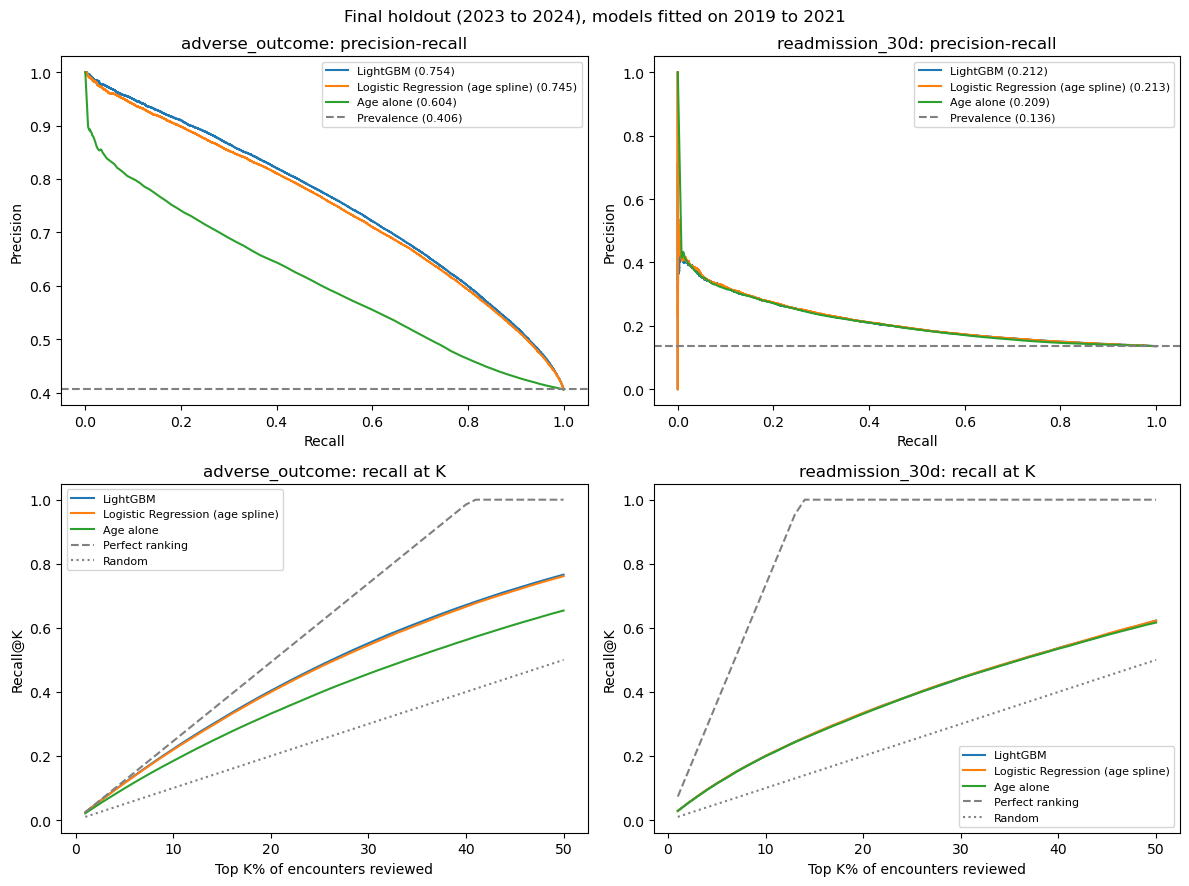

tables/final_model_ladder.csv | KB: 2.1
figures/holdout_performance.png | KB: 244.4


In [4]:
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve

mlp = pd.read_csv("../reports/tables/mlp_runs.csv")
tt = pd.read_csv("../reports/tables/tabtransformer_runs.csv")
best_mlp = {"adverse_outcome": 4, "readmission_30d": 2}   # chosen on val in Notebook 05
best_tt = {"adverse_outcome": 1, "readmission_30d": 1}    # chosen on val in Notebook 06
K_MAIN = {"adverse_outcome": 0.20, "readmission_30d": 0.10}

def val_roc(m, t):
    if m == "constant_prevalence":
        return 0.5
    if m == "age_only":
        return roc_auc_score(val[t], val["age"])
    return roc_auc_score(val[t], vp[f"{m}_{t}"].values)

notes = {"constant_prevalence": "dev prevalence for every row",
         "age_only": "age used as the score",
         "logreg": "age spline, C=0.1, median impute, no weights",
         "xgboost": "native NaN, no weights",
         "lightgbm": "selected model, native NaN, no weights"}

rows = []
for t in targets:
    r_t = res[res["target"] == t].set_index("model")
    k = K_MAIN[t]
    for m in MODELS:
        q = rk[(rk["target"] == t) & (rk["model"] == m) & np.isclose(rk["K"], k)].iloc[0]
        rows.append({"target": t, "model": m, "scored_on": "val and holdout",
                     "val_pr_auc": r_t.loc[m, "val_pr_auc"], "val_roc_auc": val_roc(m, t),
                     "holdout_pr_auc": r_t.loc[m, "pr_auc"], "holdout_pr_ci_low": r_t.loc[m, "pr_ci_low"],
                     "holdout_pr_ci_high": r_t.loc[m, "pr_ci_high"], "holdout_roc_auc": r_t.loc[m, "roc_auc"],
                     "holdout_brier": r_t.loc[m, "brier"], "holdout_ece": r_t.loc[m, "ece"],
                     "K": k, "holdout_recall_at_K": q["recall"], "holdout_precision_at_K": q["precision"],
                     "note": notes[m]})
    for name, src, pick, label in [
            ("mlp", mlp, best_mlp, "TensorFlow MLP, mean of 3 seeds, val only, rejected"),
            ("tabtransformer", tt, best_tt, "TensorFlow TabTransformer, seed 0, val only, rejected")]:
        s = src[(src["target"] == t) & (src["setting"] == pick[t])]
        rows.append({"target": t, "model": name, "scored_on": "val only",
                     "val_pr_auc": s["pr_auc"].mean(), "val_roc_auc": s["roc_auc"].mean(), "note": label})

ladder = pd.DataFrame(rows)
ladder.round(4).to_csv(tables / "final_model_ladder.csv", index=False)
print(ladder[["target", "model", "val_pr_auc", "holdout_pr_auc", "holdout_pr_ci_low", "holdout_pr_ci_high",
              "holdout_roc_auc", "holdout_brier", "holdout_ece", "K", "holdout_recall_at_K",
              "holdout_precision_at_K"]].round(4).to_string(index=False))
print("rows:", len(ladder))

# ---- figure: holdout PR curves and Recall@K ----
grid_k = np.round(np.arange(0.01, 0.51, 0.01), 2)
show_models = {"lightgbm": "LightGBM", "logreg": "Logistic Regression (age spline)", "age_only": "Age alone"}
fig, axes = plt.subplots(2, 2, figsize=(12, 9))
for c, t in enumerate(targets):
    y = hold[t].values
    ax = axes[0, c]
    for m, lb in show_models.items():
        pr_, rc_, _ = precision_recall_curve(y, P[(m, t)])
        ax.plot(rc_, pr_, label=f"{lb} ({average_precision_score(y, P[(m, t)]):.3f})")
    ax.axhline(y.mean(), ls="--", color="grey", label=f"Prevalence ({y.mean():.3f})")
    ax.set_xlabel("Recall"); ax.set_ylabel("Precision")
    ax.set_title(f"{t}: precision-recall"); ax.legend(fontsize=8)
    ax = axes[1, c]
    for m, lb in show_models.items():
        g = rank_table(y, P[(m, t)], grid_k)
        ax.plot(g["K"] * 100, g["recall"], label=lb)
    ax.plot(grid_k * 100, np.minimum(1, grid_k / y.mean()), "--", color="grey", label="Perfect ranking")
    ax.plot(grid_k * 100, grid_k, ":", color="grey", label="Random")
    ax.set_xlabel("Top K% of encounters reviewed"); ax.set_ylabel("Recall@K")
    ax.set_title(f"{t}: recall at K"); ax.legend(fontsize=8)
fig.suptitle("Final holdout (2023 to 2024), models fitted on 2019 to 2021")
fig.tight_layout()
plt.savefig(figs / "holdout_performance.png", dpi=150, bbox_inches="tight")
plt.show()

for f in ["tables/final_model_ladder.csv", "figures/holdout_performance.png"]:
    p = Path("../reports") / f
    print(f, "| KB:", round(p.stat().st_size / 1e3, 1) if p.exists() else "MISSING")

In [5]:
for sub in ["figures", "tables"]:
    print(sub)
    for p in sorted((Path("../reports") / sub).iterdir()):
        print("  ", p.name, "|", round(p.stat().st_size / 1e3, 1), "KB")
print()
print("holdout predictions (local only):",
      round(Path("../data/interim/holdout_predictions.parquet").stat().st_size / 1e6, 1), "MB")

figures
   .ipynb_checkpoints | 0.0 KB
   calibration_curve.png | 105.0 KB
   dataset_composition.png | 41.3 KB
   error_profiles.png | 166.5 KB
   holdout_performance.png | 244.4 KB
   missingness_by_outcome.png | 63.0 KB
   missingness_heatmap.png | 70.3 KB
   outcome_prevalence.png | 41.6 KB
   outcome_rates_by_feature.png | 167.1 KB
   pr_curve.png | 88.3 KB
   precision_at_k.png | 100.0 KB
   recall_at_k.png | 114.9 KB
   roc_curve.png | 115.0 KB
   shap_beeswarm_adverse_outcome.png | 149.4 KB
   shap_beeswarm_readmission_30d.png | 135.4 KB
   shap_local_adverse_outcome.png | 124.0 KB
   shap_local_readmission_30d.png | 136.7 KB
   shap_summary.png | 119.5 KB
   subgroup_performance.png | 194.6 KB
   temporal_performance.png | 71.3 KB
tables
   ablation_results.csv | 3.3 KB
   calibration_metrics.csv | 0.6 KB
   confusion_matrices_holdout.csv | 0.3 KB
   data_quality_summary.csv | 0.4 KB
   error_analysis.csv | 32.3 KB
   feature_drift_adversarial.csv | 0.2 KB
   feature_summary.c

## Part B: final holdout evaluation (2023 to 2024, 265,782 rows)

Models fitted on dev (2019 to 2021, 400,365 rows) with the settings validated in Notebooks 03 and 04: Logistic Regression (age spline, C = 0.1, median imputation, no weights), XGBoost (185 and 36 trees), LightGBM (291 and 51 trees), native NaN handling, no class weights, no calibrator. Refits reproduced the saved val predictions exactly (max difference 0.0). Holdout labels were first loaded in the evaluation cell. The evaluation ran once, and nothing changed afterwards. The MLP and TabTransformer were rejected on val and were not scored on holdout. Holdout prevalence: adverse_outcome 0.4060, readmission_30d 0.1363. No categorical value in holdout was unseen in dev.

PR-AUC with 95% bootstrap interval (200 resamples, same rows for every model). Table: reports/tables/final_model_ladder.csv.

| Model | adverse_outcome | val | readmission_30d | val |
|---|---|---:|---|---:|
| Constant prevalence | 0.4060 (0.4043 to 0.4076) | 0.4080 | 0.1363 (0.1350 to 0.1375) | 0.1360 |
| Age alone | 0.6040 (0.6005 to 0.6067) | 0.6061 | 0.2093 (0.2059 to 0.2120) | 0.2107 |
| Logistic Regression | 0.7453 (0.7429 to 0.7480) | 0.7464 | 0.2131 (0.2096 to 0.2160) | 0.2148 |
| XGBoost | 0.7535 (0.7511 to 0.7564) | 0.7548 | 0.2119 (0.2080 to 0.2151) | 0.2138 |
| LightGBM (selected) | 0.7540 (0.7515 to 0.7568) | 0.7553 | 0.2122 (0.2084 to 0.2154) | 0.2138 |
| MLP, mean of 3 seeds (val only, rejected) | not scored | 0.7494 | not scored | 0.2106 |
| TabTransformer, seed 0 (val only, rejected) | not scored | 0.7455 | not scored | 0.2104 |

ROC-AUC on holdout, adverse_outcome: age alone 0.6732, Logistic Regression 0.7978, XGBoost 0.8034, LightGBM 0.8036. readmission_30d: age alone 0.6010, Logistic Regression 0.6068, XGBoost 0.6059, LightGBM 0.6069.

Brier and ECE on holdout, uncalibrated, no class weights:

| Model | adverse_outcome Brier | ECE | readmission_30d Brier | ECE |
|---|---:|---:|---:|---:|
| Constant prevalence | 0.2412 | 0.0032 | 0.1177 | 0.0014 |
| Logistic Regression | 0.1766 | 0.0066 | 0.1147 | 0.0026 |
| XGBoost | 0.1740 | 0.0050 | 0.1148 | 0.0059 |
| LightGBM | 0.1739 | 0.0054 | 0.1148 | 0.0042 |

Paired bootstrap, PR-AUC difference for LightGBM minus each model (95% interval):
- adverse_outcome: minus constant +0.3478 (0.3455 to 0.3503), minus age alone +0.1501 (0.1475 to 0.1525), minus Logistic Regression +0.0086 (0.0078 to 0.0093), minus XGBoost +0.0005 (0.0002 to 0.0007).
- readmission_30d: minus constant +0.0757 (0.0722 to 0.0784), minus age alone +0.0028 (0.0021 to 0.0037), minus Logistic Regression -0.0010 (-0.0017 to -0.0002), minus XGBoost +0.0003 (-0.0006 to 0.0009).

## Reading the holdout result
- adverse_outcome: the val result holds. LightGBM beats Logistic Regression by +0.0086 on holdout against +0.0089 on val. LightGBM and XGBoost are a tie in practice. PR-AUC over prevalence is 1.857 on holdout and 1.851 on val for LightGBM. PR-AUC fell by 0.0011 to 0.0013 for the three fitted models, and by 0.0020 for the constant baseline, because prevalence moved from 0.408 to 0.406.
- readmission_30d: Logistic Regression is ahead of LightGBM by 0.0010 and the paired interval excludes zero (-0.0017 to -0.0002). On val the interval included zero (-0.0021 to 0.0004), with a point estimate of the same size. LightGBM was locked on val and stays the selected model, as the design block required. For this target the simplest model is as good as any, and nominally better by about 0.001.
- readmission_30d is mostly an age ranking. LightGBM beats age alone by +0.0028 (0.0021 to 0.0037) on holdout. Age alone reaches 0.2093 against 0.2122 for LightGBM.
- readmission_30d PR-AUC fell by 0.0016 to 0.0020 for the fitted models against val, while the baseline moved by +0.0002. No interval was computed for that change, and the intervals on each estimate have half-widths of about 0.003, so it is not distinguishable from sampling noise. Early stopping on val does not explain it alone, because Logistic Regression, with only C tuned, fell by 0.0016 too.
- The Brier gain of LightGBM over the constant model is 0.0029 for readmission_30d and 0.0673 for adverse_outcome. ECE stayed at 0.0054 and 0.0042 without a calibrator, as chosen in Notebook 07.

## Ranking and confusion matrices on holdout (LightGBM)
Tables: reports/tables/ranking_capacity_holdout.csv, reports/tables/confusion_matrices_holdout.csv. Ties in the age-only and constant scores are broken at random (age is an integer).

| adverse_outcome (107,920 events) | K | events captured | recall | precision | false positives |
|---|---:|---:|---:|---:|---:|
| | 5% | 12,531 of 13,289 reviewed | 0.1161 | 0.9430 | 758 |
| | 10% | 23,904 | 0.2215 | 0.8994 | 2,674 |
| | 20% | 43,543 | 0.4035 | 0.8192 | 9,613 |
| | 30% | 59,548 | 0.5518 | 0.7468 | 20,187 |
| | 40% | 72,430 | 0.6711 | 0.6813 | 33,883 |

| readmission_30d (36,216 events) | K | events captured | recall | precision | false positives |
|---|---:|---:|---:|---:|---:|
| | 1% | 1,038 of 2,658 reviewed | 0.0287 | 0.3905 | 1,620 |
| | 5% | 4,143 | 0.1144 | 0.3118 | 9,146 |
| | 10% | 7,254 | 0.2003 | 0.2729 | 19,324 |
| | 20% | 12,075 | 0.3334 | 0.2272 | 41,081 |

Confusion matrices at cut-offs fixed from val scores (80th percentile for adverse_outcome, 90th for readmission_30d):

| Target | cut-off | flagged share | TP | FP | FN | TN | precision | recall | specificity | F1 |
|---|---:|---:|---:|---:|---:|---:|---:|---:|---:|---:|
| adverse_outcome | 0.6786 | 0.1995 | 43,442 | 9,575 | 64,478 | 148,287 | 0.8194 | 0.4025 | 0.9393 | 0.5399 |
| readmission_30d | 0.2053 | 0.0993 | 7,215 | 19,174 | 29,001 | 210,392 | 0.2734 | 0.1992 | 0.9165 | 0.2305 |

The val-based cut-offs flagged 19.95% and 9.93% of holdout, so the score distribution did not shift. Risk ranking here is analytical prioritisation of a synthetic benchmark, not clinical decision support.

## Part C: where the portfolio evidence lives
Dataset summary and split: reports/tables/data_quality_summary.csv, split_summary.csv. Target prevalence: outcome_prevalence.png. Missingness: missingness_summary.csv, missingness_heatmap.png, missingness_by_outcome.png. Model comparison on val: model_comparison.csv (its Brier and ECE columns come from class-weighted Logistic Regression and are not quoted), ablation_results.csv, imbalance_comparison.csv, mlp_runs.csv, tabtransformer_runs.csv. Final results: final_model_ladder.csv, final_holdout_results.csv, holdout_paired_differences.csv. Calibration: calibration_metrics.csv, calibration_curve.png. SHAP: shap_global_importance.csv, shap_local_examples.csv and the shap_*.png